# Assignment: Animal Classification, CNN Multi-Class Image Classification

**Type:** Multi-Class Classification (CNN, built from scratch)
**Framework:** TensorFlow / Keras
**Classes (5):** `cat`, `cow`, `deep` (deer), `dog`, `lion`
**Dataset:** [Animal Image Classification, 5 Species (Kaggle)](https://www.kaggle.com/datasets/miadul/animal-image-classification-5-species)

**Pipeline:**
1. Download the dataset
2. Explore the folder structure (already split into `train` / `validation` / `test`)
3. Preprocess images (resize, normalize, augment)
4. Build a simple CNN from scratch
5. Train and validate the model
6. Evaluate (accuracy/loss curves, confusion matrix, classification report)
7. Predict on individual test images
8. Save the trained model

> **Note:** This dataset is small (~629 images across 5 classes) and already comes pre-split into `train`, `validation`, and `test` folders, so unlike some datasets we don't need to do our own train/val split, we just point Keras at each folder directly.

## Step 1: Install & Import Libraries

In [1]:
# If running in Colab, this installs kagglehub (usually pre-installed already)
!pip install -q kagglehub


In [2]:
import os
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input, Rescaling
)
from tensorflow.keras.preprocessing import image
from tensorflow.keras.utils import image_dataset_from_directory

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

import kagglehub

print("TensorFlow version:", tf.__version__)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


TensorFlow version: 2.21.0


C:\Users\Feebile\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Step 2: Download the Dataset

We use `kagglehub` to download the **Animal Image Classification, 5 Species** dataset. It already ships with `train`, `validation`, and `test` folders, each containing one sub-folder per class (`cat`, `cow`, `deep`, `dog`, `lion`).

> If `kagglehub` asks for authentication in Colab, follow the on-screen prompt to log in with your Kaggle account. If it fails entirely, see the fallback cell below for manual `kaggle.json` upload instructions.

In [3]:
# Download latest version of the dataset
dataset_path = kagglehub.dataset_download("miadul/animal-image-classification-5-species")
print("Path to dataset files:", dataset_path)


100%|██████████| 5.33M/5.33M [00:04<00:00, 1.19MB/s]

Extracting files...


Path to dataset files: C:\Users\Feebile\.cache\kagglehub\datasets\miadul\animal-image-classification-5-species\versions\1


In [4]:
# --- FALLBACK: only run this if kagglehub download fails above ---
# 1. Go to https://www.kaggle.com/settings -> "Create New API Token" -> downloads kaggle.json
# 2. Run the cells below (uncomment first) and upload kaggle.json when prompted

# from google.colab import files
# files.upload()  # upload kaggle.json here
# !mkdir -p ~/.kaggle
# !cp kaggle.json ~/.kaggle/
# !chmod 600 ~/.kaggle/kaggle.json
# !kaggle datasets download -d miadul/animal-image-classification-5-species -p animals_raw --unzip


## Step 3: Explore the Folder Structure

Kaggle datasets downloaded via `kagglehub` sometimes have an extra nested folder. We first locate the real `train` / `validation` / `test` directories so the rest of the notebook doesn't hardcode a fragile path.

In [5]:
dataset_root = Path(dataset_path)

# Find the folder that actually contains train/validation/test sub-folders
candidates = [p for p in dataset_root.rglob("*") if p.is_dir() and (p / "train").exists()]
BASE_DIR = candidates[0] if candidates else dataset_root

TRAIN_DIR = BASE_DIR / "train"
VAL_DIR = BASE_DIR / "validation"
TEST_DIR = BASE_DIR / "test"

print("Base directory:", BASE_DIR)
for split_name, split_dir in [("train", TRAIN_DIR), ("validation", VAL_DIR), ("test", TEST_DIR)]:
    classes = sorted([d.name for d in split_dir.iterdir() if d.is_dir()])
    print(f"\n{split_name} -> classes: {classes}")
    for c in classes:
        n_images = len(list((split_dir / c).glob("*.jpg"))) + len(list((split_dir / c).glob("*.jpeg")))
        print(f"   {c}: {n_images} images")


Base directory: C:\Users\Feebile\.cache\kagglehub\datasets\miadul\animal-image-classification-5-species\versions\1\animals_dataset

train -> classes: ['cat', 'cow', 'deep', 'dog', 'lion']
   cat: 91 images
   cow: 86 images
   deep: 87 images
   dog: 111 images
   lion: 89 images

validation -> classes: ['cat', 'cow', 'deep', 'dog', 'lion']
   cat: 17 images
   cow: 15 images
   deep: 17 images
   dog: 17 images
   lion: 17 images

test -> classes: ['cat', 'cow', 'deep', 'dog', 'lion']
   cat: 17 images
   cow: 16 images
   deep: 16 images
   dog: 16 images
   lion: 17 images


## Step 4: Load & Preprocess the Dataset

We use `image_dataset_from_directory` to automatically:
- Load images from the `train`, `validation`, and `test` folders
- Resize them to 128x128
- Batch them for training
- One-hot encode the 5 class labels (`label_mode="categorical"`)

In [6]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 16  # small batch size since the dataset is small (~629 images total)

train_ds = image_dataset_from_directory(
    TRAIN_DIR,
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

val_ds = image_dataset_from_directory(
    VAL_DIR,
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

test_ds = image_dataset_from_directory(
    TEST_DIR,
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)
print("Classes:", class_names)


Found 464 files belonging to 5 classes.
Found 83 files belonging to 5 classes.
Found 82 files belonging to 5 classes.
Classes: ['cat', 'cow', 'deep', 'dog', 'lion']


### Visualize Some Training Images

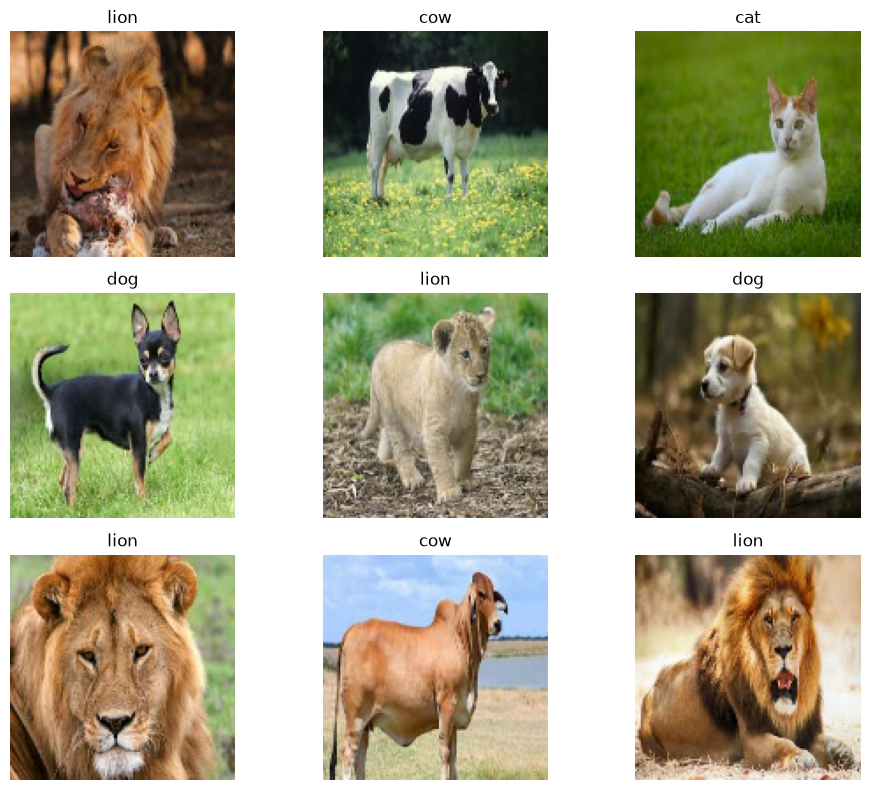

In [7]:
plt.figure(figsize=(10, 8))

for images, labels in train_ds.take(1):
    for i in range(min(9, images.shape[0])):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        class_index = int(tf.argmax(labels[i]))
        plt.title(class_names[class_index])
        plt.axis("off")

plt.tight_layout()
plt.show()


### Data Augmentation & Performance Optimization

Since our dataset is very small (a few hundred images), we apply light augmentation (random flip, rotation, zoom) to the training set to reduce overfitting. We also prefetch batches for faster training.

In [8]:
data_augmentation = Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=AUTOTUNE
).prefetch(buffer_size=AUTOTUNE)

val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)


## Step 5: Build the CNN Model (From Scratch)

A simple architecture with 3 convolution + pooling blocks, followed by dense layers and a **softmax** output over the 5 classes (since this is multi-class, not binary).

In [9]:
model = Sequential([
    Input(shape=(128, 128, 3)),

    # Normalize pixel values to [0, 1]
    Rescaling(1./255),

    # Convolution Block 1
    Conv2D(32, (3, 3), activation="relu"),
    MaxPooling2D(),

    # Convolution Block 2
    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D(),

    # Convolution Block 3
    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D(),
    Dropout(0.25),

    # Classification head
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),

    # Multi-class output: one probability per animal class
    Dense(NUM_CLASSES, activation="softmax")
])

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,285 (12.61 MB)

 Trainable params: 3,305,285 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

## Step 6: Compile the Model

In [10]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


## Step 7: Train the CNN

We use **EarlyStopping** to halt training once validation loss stops improving, restoring the best-performing weights. Since the dataset is tiny, we train for a modest number of epochs to reduce the risk of overfitting.

In [11]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

EPOCHS = 20

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stop]
)


Epoch 1/20


C:\Users\Feebile\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


29/29 ━━━━━━━━━━━━━━━━━━━━ 12s 330ms/step - accuracy: 0.2349 - loss: 1.6708 - val_accuracy: 0.2048 - val_loss: 1.6025
Epoch 2/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 261ms/step - accuracy: 0.2478 - loss: 1.6003 - val_accuracy: 0.2169 - val_loss: 1.5707
Epoch 3/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 260ms/step - accuracy: 0.3190 - loss: 1.5492 - val_accuracy: 0.2651 - val_loss: 1.5412
Epoch 4/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 275ms/step - accuracy: 0.3427 - loss: 1.5050 - val_accuracy: 0.3976 - val_loss: 1.4157
Epoch 5/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 285ms/step - accuracy: 0.3966 - loss: 1.4339 - val_accuracy: 0.3855 - val_loss: 1.4234
Epoch 6/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 284ms/step - accuracy: 0.3621 - loss: 1.4522 - val_accuracy: 0.3614 - val_loss: 1.3810
Epoch 7/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 286ms/step - accuracy: 0.4332 - loss: 1.3793 - val_accuracy: 0.5060 - val_loss: 1.3081
Epoch 8/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 287ms/step - accuracy: 0.4720 - loss: 1.3104 - val_accuracy: 0.4096 - val

## Step 8: Plot Training & Validation Accuracy / Loss

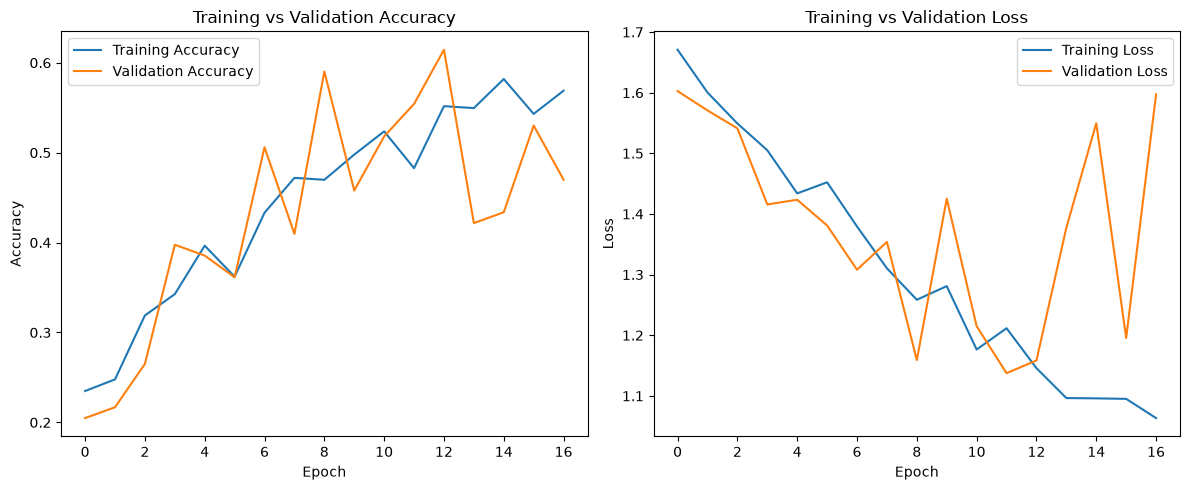

In [12]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.tight_layout()
plt.show()


## Step 9: Evaluate the Model on the Test Set

In [13]:
test_loss, test_accuracy = model.evaluate(test_ds)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - accuracy: 0.4634 - loss: 1.3139
Test Loss: 1.3139
Test Accuracy: 0.4634


### Confusion Matrix & Classification Report

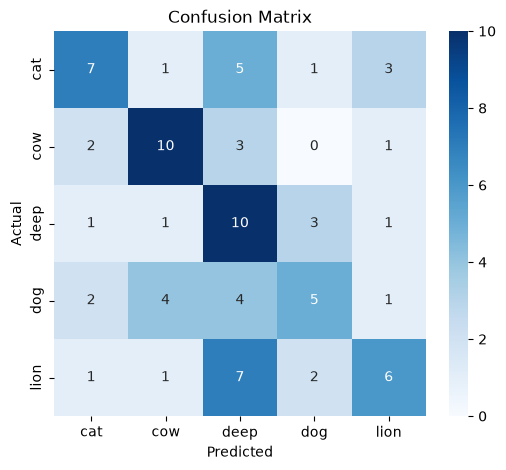

              precision    recall  f1-score   support

         cat       0.54      0.41      0.47        17
         cow       0.59      0.62      0.61        16
        deep       0.34      0.62      0.44        16
         dog       0.45      0.31      0.37        16
        lion       0.50      0.35      0.41        17

    accuracy                           0.46        82
   macro avg       0.49      0.47      0.46        82
weighted avg       0.49      0.46      0.46        82



In [14]:
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)
    y_true.extend(tf.argmax(labels, axis=1).numpy())
    y_pred.extend(tf.argmax(predictions, axis=1).numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))


## Step 10: Predict on a New/Unseen Test Image

Provide the path to any test image to see the model's prediction and confidence score.

In [15]:
def predict_image(img_path):
    img = image.load_img(img_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array, verbose=0)[0]
    predicted_index = int(np.argmax(predictions))
    predicted_class = class_names[predicted_index]
    confidence = predictions[predicted_index]

    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Prediction: {predicted_class}\nConfidence: {confidence * 100:.2f}%")
    plt.show()

    return predicted_class, confidence

# Example usage (replace with an actual image path):
# predict_image(str(TEST_DIR / "lion" / "some_image.jpg"))


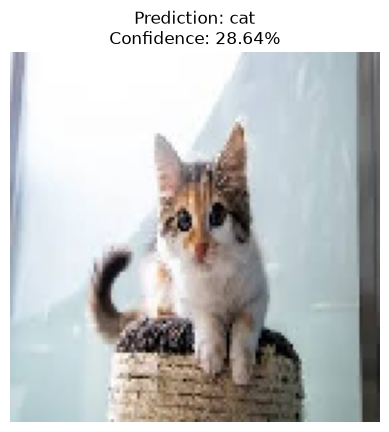

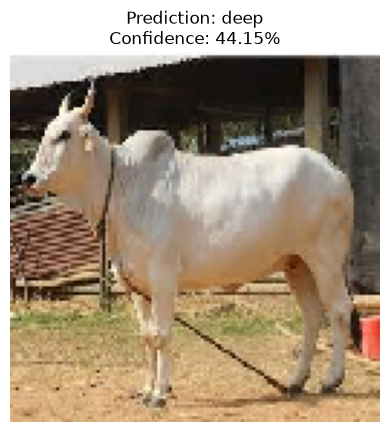

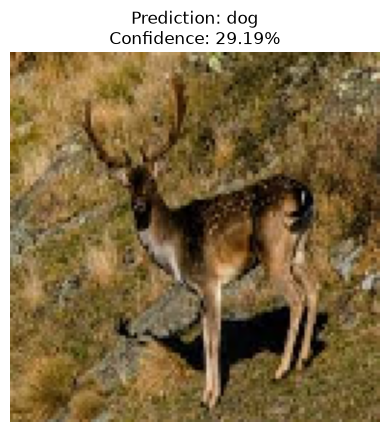

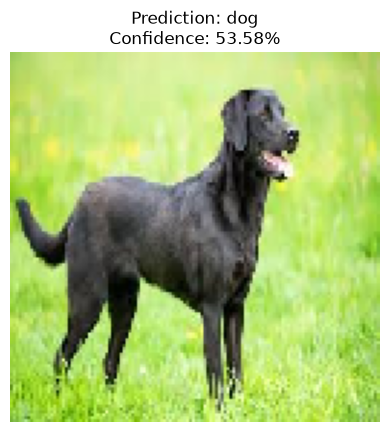

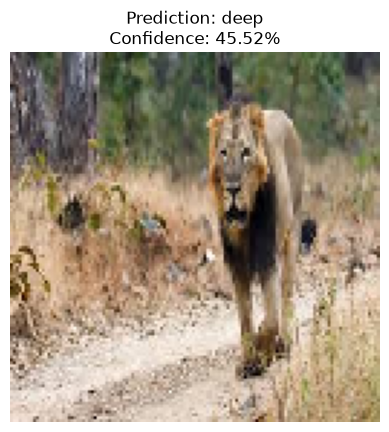

In [16]:
# Quick sanity check: predict on one image from each class in the test set
for class_name in class_names:
    class_dir = TEST_DIR / class_name
    sample_images = list(class_dir.glob("*.jpg")) + list(class_dir.glob("*.jpeg"))
    if sample_images:
        predict_image(str(sample_images[0]))


## Step 11: Save the Trained Model

In [17]:
model.save("animal_classification_cnn.keras")
print("Model saved successfully as 'animal_classification_cnn.keras'")

# To reload later:
# model = tf.keras.models.load_model("animal_classification_cnn.keras")


Model saved successfully as 'animal_classification_cnn.keras'


## Conclusion

- **Objective:** Classify images into 5 animal categories (`cat`, `cow`, `deep`/deer, `dog`, `lion`) using a CNN.
- **Dataset:** Animal Image Classification, 5 Species (Kaggle), pre-split into `train`, `validation`, and `test` folders (~629 images total).
- **Preprocessing:** Images resized to 128x128, normalized to [0, 1], and lightly augmented (flip, rotation, zoom) during training.
- **Model Architecture:** 3 convolutional blocks (32 → 64 → 128 filters) with max pooling, followed by a dense layer, dropout, and a softmax output over 5 classes.
- **Training:** Adam optimizer, categorical cross-entropy loss, early stopping on validation loss.
- **Evaluation:** Accuracy/loss curves, confusion matrix, and a per-class precision/recall/F1-score report.
- **Prediction:** The trained model can classify new, unseen animal images with a confidence score.

> **Note:** This is a small, basic-level classroom dataset (~629 images across 5 classes). Real-world deployment would need a much larger and more diverse dataset, plus more rigorous evaluation, to be reliable.